# Weak Supervision


## Introduction

In this section, we apply what we learned in this chapter to implement **weak supervision**.
The idea behind weak supervision is that for each data point there is a latent true label that is inaccessible to us (even during training), instead we utilize weak signals from user-defined **labeling functions** (LF). The material here is an exposition and implementation of the **data programming** approach to weak supervision using LFs described in [@data-programming].

LFs can be thought of as heuristic rules that can be applied to a large subset of the data. In case the LF is not applicable, then the function simply abstains from making a prediction. Note that this is a realistic scenario, it's easier to describe rules than to manually annotate a large number of data. LFs provides noisy, less expensive labels, which can be useful in training noise-aware discriminative models. 

![**Weak supervision training pipeline**. The third image is flipped (i.e. the flow of prediction is right to left.) 
These two tasks will be implemented in this notebook. [Source](https://cs.brown.edu/people/sbach/files/bach-icml17-slides.pdf)](./img/01-weak-supervision-pipeline.png)

### Labeling Functions (LF)

Suppose we have a large corpus of IMDB movie reviews that we want to classify as positive or negative. Manually labeling thousands of reviews is expensive, but we can write heuristic rules called **labeling functions** (LF) that capture common patterns. Each LF inspects a review and returns `+1` (positive), `-1` (negative), or `0` (abstain). LFs can exploit many kinds of signals — word counts, explicit ratings, viewing behavior, or comparative language:

In [ ]:
import re
import numpy as np
import torch
import pandas as pd
from datasets import load_dataset

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

ds = load_dataset("imdb")
train_ds = ds["train"].shuffle(seed=RANDOM_SEED).select(range(3000))
train_texts = train_ds["text"]
y_train_imdb = np.array([2 * label - 1 for label in train_ds["label"]])  # {0, 1} -> {-1, +1}

POSITIVE, NEGATIVE, ABSTAIN = 1, -1, 0

Sample IMBb movie review (text) from the dataset:

In [57]:
print(y_train_imdb[0])
print("\n".join([train_texts[0][a: a + 80] for a in range(0, len(train_texts[0]), 80)]))

1
We always watch American movies with their particular accents from each region (
south, west, etc). We have the same here. All foreign people must to watch this 
movie and need to have a open mind to accept another culture, besides American a
nd European almost dominate the cinematographic industry.<br /><br />This movie 
tell us about a parallel world which it isn't figured even for those who live in
 a big city like São Paulo. All actors are improvising and they are very realist
ic. The camera give us an idea of their confuse world, the loneliness of each ch
aracter and invite us to share their world.<br /><br />It's a real great movie a
nd worst a rent even have it at home.


Example LFs for sentiment classification of IMDb reviews:

In [29]:
def lf_sentiment_words(text):
    text = text.lower()
    pos_count = sum(1 for w in ["great", "love", "amazing", "fun"] if w in text)
    neg_count = sum(1 for w in ["bad", "waste", "boring", "stupid"] if w in text)
    if pos_count > neg_count: return POSITIVE
    if neg_count > pos_count: return NEGATIVE
    return ABSTAIN

def lf_viewing_experience(text):
    text_lower = text.lower()
    pos_watch = ["watched twice", "watch again", "rewatch", "couldn't stop watching"]
    neg_watch = ["walked out", "turned it off", "fell asleep", "couldn't finish"]
    pos = any(p in text_lower for p in pos_watch)
    neg = any(n in text_lower for n in neg_watch)
    if pos and not neg: return POSITIVE
    if neg and not pos: return NEGATIVE
    return ABSTAIN

def lf_comparative_sentiment(text):
    text_lower = text.lower()
    if "worse than" in text_lower or "not as good as" in text_lower:
        return NEGATIVE
    return ABSTAIN

Consider these example reviews and notice how each LF can be fooled or simply silent:

In [30]:
review = "I've watched this twice already and couldn't stop watching — the pacing is superb."

print("lf_sentiment_words        ", lf_sentiment_words(review))     
print("lf_viewing_experience     ", lf_viewing_experience(review))  
print("lf_comparative_sentiment  ", lf_comparative_sentiment(review))

lf_sentiment_words         0
lf_viewing_experience      1
lf_comparative_sentiment   0


In [31]:
review = "An excellent way to waste your Friday night — worse than anything I've seen this year."

print("lf_sentiment_words        ", lf_sentiment_words(review))     
print("lf_viewing_experience     ", lf_viewing_experience(review))  
print("lf_comparative_sentiment  ", lf_comparative_sentiment(review))

lf_sentiment_words         -1
lf_viewing_experience      0
lf_comparative_sentiment   -1


In [32]:
review = """
This movie is an absolute DISASTER. Two hours of my life I'll never get back.
The plot makes zero sense, the acting is wooden, and the dialogue sounds like
it was written by a toddler. Every scene drags on forever. I've seen better
cinematography in a high school project. The sound mixing is atrocious — I
couldn't finish it. Zero stars.
"""

print("lf_sentiment_words        ", lf_sentiment_words(review))     
print("lf_viewing_experience     ", lf_viewing_experience(review))  
print("lf_comparative_sentiment  ", lf_comparative_sentiment(review))

lf_sentiment_words         0
lf_viewing_experience      -1
lf_comparative_sentiment   0


### LF parameters

A labeling function is characterized by its **coverage** (fraction of inputs where it does not abstain) and **accuracy** (fraction correct among non-abstaining inputs). For the IMDB task, a full set of seven LFs has the following profile:

| LF | Coverage | Accuracy |
| :-: | :-: | :-: |
| `lf_strong_sentiment` | 0.41 | 0.88 |
| `lf_sentiment_words` | 0.69 | 0.76 |
| `lf_rating_mention` | 0.02 | 0.81 |
| `lf_viewing_experience` | 0.01 | 0.81 |
| `lf_comparative_sentiment` | 0.01 | 0.80 |
| `lf_recommendation` | 0.11 | 0.80 |
| `lf_exclamation_sentiment` | 0.05 | 0.81 |

[There is a natural trade-off:]{.underline} LFs with broad coverage (like `lf_sentiment_words`) tend to be less accurate, while highly accurate LFs fire on fewer reviews (`lf_strong_sentiment` is a massive exemption). The full definitions of these LFs and their application to IMDB data appear in the [application section](#application-imdb-movie-reviews) at the end of this notebook.

**Remark.** Note that we generally do not have access to true labels for a representative sample of our dataset. Hence, even estimating the parameters of our LFs are not possible. The following sections will deal with algorithms for estimating these parameters as well as training a machine learning model with noisy labels.

Each LF has its own **confusion matrix** showing how its outputs relate to the true labels. For instance, `lf_sentiment_words` has asymmetric accuracy — it is much better at identifying positive reviews than negative ones:

In [ ]:
from sklearn.metrics import confusion_matrix as cm

lf_preds = np.array([lf_sentiment_words(t) for t in train_texts])
abstained = lf_preds == 0

preds = lf_preds[~abstained]
labels = y_train_imdb[~abstained]
labels_abs = pd.Series(y_train_imdb[abstained]).value_counts().to_dict()

confmat = cm(labels, preds, labels=[-1, 1])
df = pd.DataFrame(confmat, index=["y=-1", "y=+1"], columns=["pred=-1", "pred=+1"])
df["pred=0"] = None
df.loc["y=+1", "pred=0"] = labels_abs.get(1, 0)
df.loc["y=-1", "pred=0"] = labels_abs.get(-1, 0)

df

,pred=-1,pred=+1,pred=0
y=-1,485,387,636
y=+1,76,875,541


:::{.callout-tip}
In practice, LFs are **iteratively refined**: we inspect disagreements between LFs, compare against any available ground truth, and consult domain knowledge. Since LFs are user-defined heuristics, they require some expertise and data exploration to be effective.
:::

## Basic theory


For simplicity, we will limit our presentation to binary classification, although the method extends easily to the multiclass setting. For each data point $\textbf{\textsf{x}} \in \mathcal{X},$ the latent true label is denoted by $y \in \mathcal{Y} = \{-1, +1\}$. Suppose we have $n$ **labeling functions** $\lambda_j\colon \mathcal{X} \to \mathcal{Y} \cup \{0\}.$ The extra label $0$ is for when the LF is not applicable to the given input, i.e. the LF **abstains**. Hence, given data points $\textbf{\textsf{x}}_i,$ then we get an $m \times n$ matrix of LF outputs $\Lambda_{ij} = \lambda_j(\textbf{\textsf{x}}_i)$.

Our first step is to estimate the distribution $p_{\delta, \gamma}(\Lambda=\lambda(\textbf{\textsf{x}}), Y=y)$ defined as the probability that LFs output $\lambda(\textbf{\textsf{x}}) = (\lambda_1(\textbf{\textsf{x}}), \ldots, \lambda_n(\textbf{\textsf{x}}))$ for a test instance $\textbf{\textsf{x}}$ with true label $y$. We do MLE to find parameters $\hat{\delta}$ and $\hat{\gamma}$ that maximize the marginal probability $p(\Lambda_{ij})$ of the observed LF outputs. The parameters are **coverage** $\delta = (\delta_1, \ldots, \delta_n)$ and **accuracy** $\gamma = (\gamma_1, \ldots, \gamma_n)$ of each LF. 

Finally, a **noise-aware** discriminative model $f_\Theta$ is trained by minimizing the ff. loss:

$$
\mathcal{L}_{\text{clf}}(\Theta) = 
\frac{1}{m}\sum_{i=1}^m \sum_{y_i=-1,+1} 
\ell(f_\Theta(\textbf{\textsf{x}}_i), y_i) \cdot 
{p_{\hat{\delta}, \hat{\gamma}}(Y = y_i \mid \Lambda = \lambda(\textbf{\textsf{x}}_i))}
$$

where $\ell$ is the usual loss criterion. This looks like the usual loss, except we don't have a single label. All labels contribute weighted by the probability of the label given the labeling of the input.

### Generative model

For each LF $\lambda_j$ we assign two parameters $(\delta_j, \gamma_j)$ corresponding to its **coverage** and **accuracy**. Coverage $\delta_j$ is defined as the probability of labeling an input, and accuracy as $\gamma_j$ as the probability of labeling it correctly. This assumes that the LFs have the same distribution for each label (e.g. not more accurate when the label is positive). Moreover, we assume that LF outputs are independent of each other. Hence,

$$
\begin{aligned}
p_{\delta, \gamma}(\Lambda = \lambda(\textbf{\textsf{x}})) 
&= \sum_{y=-1,+1}  p_{\delta, \gamma}(\Lambda = \lambda(\textbf{\textsf{x}}), Y = y) \\
&= \sum_{y=-1,+1} p(Y = y) \cdot p_{\delta, \gamma}(\Lambda = \lambda(\textbf{\textsf{x}}) \mid Y = y) \\
&= \sum_{y=-1,+1} p(Y = y) \cdot \prod_{j=1}^n \begin{cases} 
1 - \delta_j \quad& \phantom{y}\lambda_j(\textbf{\textsf{x}}) &= \phantom{-}0 \\
\delta_j\gamma_j \quad& y \lambda_j(\textbf{\textsf{x}}) &= +1 \\
\delta_j(1 - \gamma_j) \quad& y \lambda_j(\textbf{\textsf{x}}) &= -1 \\
\end{cases}.
\end{aligned}
$$

Our goal therefore is to perform MLE on $(\delta, \gamma)$ with the ff. loss:


$$
\begin{aligned}
\mathcal{L}_{\text{gen}}({\delta}, {\gamma}) 
&= \sum_{i=1}^m -\log \; p_{\delta, \gamma}(\Lambda_{i}) \\
&= \sum_{i=1}^m -\log 
\left( 
    \sum_{y=-1,+1} p_y 
    \cdot 
    \prod_{j=1}^n 
    \begin{cases} 
        1 - \delta_j            \quad& \phantom{y}\Lambda_{ij} &= \phantom{-}0 \\
        \delta_j\gamma_j        \quad&          y \Lambda_{ij} &= +1 \\
        \delta_j(1 - \gamma_j)  \quad&          y \Lambda_{ij} &= -1
    \end{cases} 
\right).
\end{aligned}
$$


:::{.callout-note}
**The symmetric confusion matrix is a strong simplifying assumption.** In general, each LF has a full $K \times (K+1)$ confusion matrix conditioned on the true label (including abstention). The rows of this matrix — one per true class — need not be identical: an LF may fire more often on positive examples, or be more accurate when the true label is negative. The simplified model collapses this to just $2N$ parameters (one coverage $\delta_j$ and one accuracy $\gamma_j$ per LF), while the general model learns all entries of the per-LF confusion matrix, requiring $K(K+1-1) \cdot N = K^2 N$ free parameters (since each row of the confusion matrix sums to 1). For binary classification that is $4N$ vs $2N$. We stick with the simplified model here.
:::

### Code implementation

We implement the above equations using some clever indexing:

In [5]:
import torch
torch.manual_seed(1)

delta = torch.tensor([0.3, 0.3, 0.3, 0.3])  # coverage
gamma = torch.tensor([0.7, 0.6, 0.8, 0.9])  # accuracy

n = 4
L = torch.tensor([
    [-1,  0, +1, +1],
    [+1, -1, -1,  0],
])

params = torch.stack([
    1 - delta,              # abstained
    delta * gamma,          # accurate
    delta * (1 - gamma)     # inaccurate
], dim=0)

params  # Note sum along dim=0 is 1, i.e. sum of all p(λ | y) for λ = -1, 0, 1 is 1.

tensor([[0.7000, 0.7000, 0.7000, 0.7000],
        [0.2100, 0.1800, 0.2400, 0.2700],
        [0.0900, 0.1200, 0.0600, 0.0300]])

We will use the empirical LF matrix to pick out the appropriate weight given its value:

In [ ]:
# p(L | y = +1)
# fancy pytorch indexing: params[L[i, j], j] -> out shape = L.shape
params[L, torch.arange(n)]  

tensor([[0.0900, 0.7000, 0.2400, 0.2700],
        [0.2100, 0.1200, 0.0600, 0.7000]])

Notice that non-abstained probabilities will flip:

In [7]:
# p(L | y = -1)
params[-L, torch.arange(n)]

tensor([[0.2100, 0.7000, 0.0600, 0.0300],
        [0.0900, 0.1800, 0.2400, 0.7000]])

Let $p_{y=-1} = 0.7$ and $p_{y=+1} = 0.3$. The marginal probability of the LF outputs for each instance is:

In [8]:
py = [0.0, 0.5, 0.5]    # zero-index = dummy
p_pos = py[+1] * (params[+L, torch.arange(n)]).prod(dim=1) 
p_neg = py[-1] * (params[-L, torch.arange(n)]).prod(dim=1) 
p = p_pos + p_neg
p

tensor([0.0022, 0.0019])

Note that we generally have $m \gg 1$ terms with valuees in $[0, 1].$ So we use $\log$ to convert the product to a sum:

In [9]:
print("     p(Λ):", p.prod().item())
print("-log p(Λ):", -torch.log(p).sum().item())

     p(Λ): 4.107915628992487e-06
-log p(Λ): 12.402594566345215


## Experiments

In [10]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import random
import numpy as np
import pandas as pd

from notebooks.plot import set_format
set_format("svg")

RANDOM_SEED = 0
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = (
    torch.device("cuda:0") if torch.cuda.is_available() else (
        torch.device("mps") if torch.mps.is_available() else 
            torch.device("cpu")
    )
)

print(f"Using device: {DEVICE}")

Using device: mps


### Simulated LFs

Generating a toy dataset. Also setting the prior label probabilities:

In [11]:
m = 10000
LABEL_PROBS = {-1: 0.40, 1: 0.60}
y_true = np.random.choice([-1, 1], size=m, p=[LABEL_PROBS[-1], LABEL_PROBS[1]])

s = 2 * torch.pi * torch.rand(m, 1)
r = 0.5 * (torch.tensor(y_true).view(-1, 1) + 1)    # -1 -> r = 0, +1 -> r = 1
x = torch.cat([r * torch.cos(s), r * torch.sin(s)], dim=1) + 0.05 * torch.randn(m, 2)

t = np.linspace(0, 2*np.pi, 100)
x0 = 0.5 * np.cos(t)
x1 = 0.5 * np.sin(t)
x_neg = x[torch.where(torch.tensor(y_true) == -1)]
x_pos = x[torch.where(torch.tensor(y_true) == +1)]

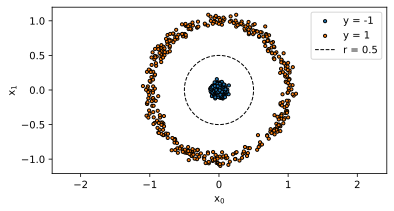

In [12]:
#| code-fold: true
def plot_dataset(x_neg, x_pos):
    m = len(x_neg)
    limit = m // 10
    plt.figure(figsize=(6, 3))
    plt.scatter(x_neg[:limit, 0], x_neg[:limit, 1], s=10.0, edgecolor="k", color="C0", label="y = -1")
    plt.scatter(x_pos[:limit, 0], x_pos[:limit, 1], s=10.0, edgecolor="k", color="C1", label="y = 1")
    plt.plot(x0, x1, color='black', linewidth=1, linestyle='dashed', label="r = 0.5")
    plt.xlabel("x$_0$")
    plt.ylabel("x$_1$")
    plt.legend()
    plt.axis("equal")

plot_dataset(x_neg, x_pos)

**Figure.** Below we use $r = 0.5$ as basis for synthetic LFs.

Note that radius less than 0.5 determines the label as negative (with high probability):

In [13]:
# 2x - 1: [0, 1] -> [-1, 1] 
((2 * (torch.sqrt((x ** 2).sum(dim=1)) >= 0.5).float() - 1).numpy() == y_true).mean()

np.float64(1.0)

We use this to write simulated LFs with given parameters:

In [14]:
def lf_sim(coverage, accuracy):
    def predict(x):
        m = x.shape[0]
        cov_mask = torch.rand(m) < coverage
        acc_mask = torch.tensor(np.random.choice([-1, 1], size=sum(cov_mask).item(), p=[1 - accuracy, accuracy]))
        y = 2 * (torch.sqrt((x ** 2).sum(dim=1)) >= 0.5).long() - 1
        y[cov_mask == 0] = 0
        y[cov_mask == 1] *= acc_mask
        return y
    return predict

# example
p = lf_sim(0.3, 0.8)(x).numpy()
print("cov: ", (p != 0).mean())
print("acc: ", (p[p != 0] == y_true[p != 0]).mean())
print("acc+:", (p[(p != 0) & (y_true == +1)] == y_true[(p != 0) & (y_true == +1)]).mean())
print("acc-:", (p[(p != 0) & (y_true == -1)] == y_true[(p != 0) & (y_true == -1)]).mean())

cov:  0.2993
acc:  0.7958569996658871
acc+: 0.7883418222976797
acc-: 0.8066884176182708


Initializing the empirical LF matrix. Some have fairly low accuracy:

In [15]:
lf_params = [(0.30, 0.75), (0.50, 0.65), (0.40, 0.70), (0.20, 0.80), (0.25, 0.90)]
labeling_funcs = [lf_sim(*param) for param in lf_params]

df = pd.DataFrame({"y": y_true})
df["x0"] = x[:, 0].numpy()
df["x1"] = x[:, 1].numpy()
for j, lf in enumerate(labeling_funcs):
    df[f"LF{j + 1}"] = lf(x).int().numpy()

print(df.shape)
df.head()

(10000, 8)


,y,x0,x1,LF1,LF2,LF3,LF4,LF5
0,1,-1.099107,0.056581,0,0,-1,0,0
1,1,0.102344,-0.986159,1,0,1,0,1
2,1,0.792552,0.459719,0,0,0,0,1
3,1,0.682795,0.809001,0,0,-1,0,1
4,1,-0.315244,0.901337,0,-1,-1,-1,1


Splitting for evaluation:

In [16]:
# 80-20
SPLIT_RATIO = 0.80
m = x.shape[0]
x_train = x[:int(SPLIT_RATIO * m)]
x_valid = x[int(SPLIT_RATIO * m):]
y_train = torch.tensor(y_true[:int(SPLIT_RATIO * m)])
y_valid = torch.tensor(y_true[int(SPLIT_RATIO * m):])

### Generative model training

In [17]:
class GenModel:
    def __init__(self, labeling_funcs: list, label_probs: dict):
        self.lfs = labeling_funcs
        self.py = torch.tensor([0.0, label_probs[1], label_probs[-1]])  # zero-index = dummy
        self.params = None

    def loss_fn(self, L):
        p_pos = self.infer_joint_proba(L, +1)
        p_neg = self.infer_joint_proba(L, -1)
        p = p_pos + p_neg   # Note: p has shape [m,]
        return -torch.log(p).mean()

    def fit(self, x_train, x_valid=None, bs=32, epochs=1, lr=0.0001, lr_decay=1.0):
        """MLE estimate of coverage and accuracy parameters of LFs."""
        L_train = self.lf_outputs(x_train)
        L_valid = self.lf_outputs(x_valid) if x_valid is not None else None
        m, n = L_train.shape

        delta = torch.randn(n, requires_grad=True)  # coverage score
        gamma = torch.randn(n, requires_grad=True)  # accuracy score
        delta.retain_grad()
        gamma.retain_grad()

        history = {"train": [], "valid": [], "valid_steps": []}
        checkpoint = (None, np.inf)

        try:
            for e in tqdm(range(epochs)):
                B = torch.randperm(m)
                for i in range(m // bs):
                    batch = B[i * bs: (i + 1) * bs]

                    # Note: weights are scores => need to convert to probs (p = σ(w))
                    p_delta = 1. / (1. + torch.exp(-delta))
                    p_gamma = 1. / (1. + torch.exp(-gamma))
                    self.params = torch.stack([
                        1 - p_delta,                # abstained
                        p_delta * p_gamma,          # accurate
                        p_delta * (1 - p_gamma)     # inaccurate
                    ], dim=0)

                    loss = self.loss_fn(L_train[batch])
                    loss.backward(retain_graph=True)

                    with torch.no_grad():
                        delta -= lr * (lr_decay ** (e / epochs)) * delta.grad
                        gamma -= lr * (lr_decay ** (e / epochs)) * gamma.grad
                        delta.grad = None
                        gamma.grad = None

                    history["train"].append(loss.item())
                
                with torch.no_grad():
                    if L_valid is not None:
                        val_loss = self.loss_fn(L_valid)
                        history["valid"].append(val_loss.item())
                        history["valid_steps"].append((e + 1) * (m // bs))
                        if val_loss.item() < checkpoint[1]:
                            checkpoint = (self.params, val_loss.item())

        except KeyboardInterrupt:
            print("Training stopped.")

        finally:
            # Note: model is agnostic to relabeling. Row swap when model confuses +1 and -1.
            self.params = checkpoint[0]
            if (self.params[1, :] / (1 - self.params[0, :])).mean() < 0.5:
                row_swap = torch.tensor([[1, 0, 0], [0, 0, 1], [0, 1, 0]]).float()
                self.params = row_swap @ self.params
            
            return history
    
    def predict(self, x, t=0.5):
        """Label inference using p(y | Λ_i)."""
        L = self.lf_outputs(x)
        p = self.target_cond_proba(+1, L) >= t
        return 2 * p.long() - 1
    
    def target_cond_proba(self, y, L):
        """Estimate of target prob given LF observations, i.e. p(y | Λ)."""
        p_neg = self.infer_joint_proba(L, -1)            # p(Λ_i, y=-1)
        p_pos = self.infer_joint_proba(L, +1)            # p(Λ_i, y=+1)
        p_tot = p_neg + p_pos                            # p(Λ_i) for i = 1, ..., m
        return self.infer_joint_proba(L, y) / p_tot      # p(y | Λ_i) = p(Λ_i, y) / p(Λ_i)
    
    def infer_joint_proba(self, L, y: int):
        """Return the estimated joint proba p(Λ_i, y), i.e. the output has shape [m,]."""
        n = L.shape[1]
        return self.py[y] * self.params[y * L, torch.arange(n)].prod(dim=1)     # p(Λ_i, y) = p(Λ_i | y) p(y)
    
    def lf_outputs(self, x):
        """Construct Λ matrix from LFs."""
        L = torch.stack([lf(x) for lf in self.lfs], dim=1)
        return L.long()


gen_model = GenModel(labeling_funcs, LABEL_PROBS)
history = gen_model.fit(x_train, x_valid, bs=4096, epochs=25000, lr=0.003, lr_decay=0.8)

100%|██████████| 25000/25000 [00:50<00:00, 494.02it/s]


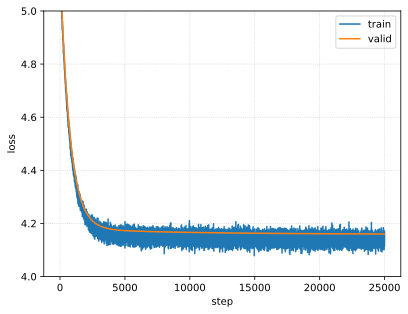

In [18]:
#| code-fold: true
plt.plot(history["train"], label="train")
plt.plot(history["valid_steps"], history["valid"], label="valid")
plt.ylabel("loss")
plt.xlabel("step")
plt.ylim(4, 5)
plt.legend()
plt.grid(linestyle="dotted", alpha=0.6)

In [19]:
print("latent:")
print([f"{cov:.4f}" for cov, acc in lf_params])
print([f"{acc:.4f}" for cov, acc in lf_params])

latent:
['0.3000', '0.5000', '0.4000', '0.2000', '0.2500']
['0.7500', '0.6500', '0.7000', '0.8000', '0.9000']


Model is able to learn the latent probabilities better when coverage is high:

In [20]:
print("estimate:")
print([f"{cov:.4f}" for cov in (1 - gen_model.params[0, :]).tolist()])
print([f"{acc:.4f}" for acc in (gen_model.params[1, :] / (1 - gen_model.params[0, :])).tolist()])

estimate:
['0.2975', '0.5003', '0.3941', '0.2025', '0.2454']
['0.7269', '0.6704', '0.6650', '0.7930', '0.7476']


The trained model can be used to estimate joint probabilities of LF outputs and targets:

In [21]:
l = torch.tensor([[-1, -1, -1, -1, -1]])
print(gen_model.infer_joint_proba(l, y=+1).item())
print(gen_model.infer_joint_proba(l, y=-1).item())

2.7557027806324186e-06
0.00022405109484679997


The conditional probabilities of targets given LF outputs sum to 1:

In [22]:
# Simple test that the model learned (without using latent labels):
l = torch.tensor([[-1, -1, -1, -1, -1]])
print(gen_model.target_cond_proba(+1, l).item())
print(gen_model.target_cond_proba(-1, l).item())

0.012150000780820847
0.98785001039505


### Label inference

Soft labels can be generated for a test input using $p_{\hat{\theta}}(y \mid \lambda(\textbf{\textsf{x}}))$ calculated using learned LF parameters. This already takes into account the prior label distribution. In particular, if $\lambda(\textbf{\textsf{x}}) = \boldsymbol{0}$, then the model falls back to the prior label distribution. Evaluating using latent labels:

In [23]:
from sklearn.metrics import (
    f1_score, 
    confusion_matrix, 
    precision_score, 
    recall_score
)

import warnings
warnings.filterwarnings("ignore")


def evaluate(model, x, y, t=0.5, verbose=True):
    m = x.shape[0]
    preds = model.predict(x) if t is None else model.predict(x, t)
    f1 = f1_score(y.numpy(), preds.numpy(), average="weighted")
    recall = recall_score(y.numpy(), preds.numpy(), average="weighted")
    precision = precision_score(y.numpy(), preds.numpy(), average="weighted")
    
    if verbose:
        print(confusion_matrix(y.numpy(), preds.numpy()))
    
    return {
        "f1": f1,
        "recall": recall,
        "precision": precision,
        "m": m, "message": f"m={m}, f1={f1:.5f}, t={t:.5f}"
    }

print(evaluate(gen_model, x_train, y_train)["message"]); print()
print(evaluate(gen_model, x_valid, y_valid)["message"])

[[1907 1336]
 [ 713 4044]]
m=8000, f1=0.73814, t=0.50000

[[ 489  297]
 [ 185 1029]]
m=2000, f1=0.75507, t=0.50000


### Noise-aware training

Noise-aware training amounts to weighting the loss with the estimate of the generative model for each target ${p_{\hat{\theta}}(y \mid \lambda(\textbf{\textsf{x}}))} = {p_{\hat{\theta}}(y, \lambda(\textbf{\textsf{x}}))}\, /\, {p_{\hat{\theta}}(\lambda(\textbf{\textsf{x}}))}.$ This allows us to train a model without labels:

In [24]:
import torch.nn as nn
from tempfile import NamedTemporaryFile
np.random.seed(42); torch.manual_seed(42)


class NoiseAwareTrainer:
    def __init__(self, clf, gen_model, labeling_funcs: list):
        self.clf = clf
        self.lfs = labeling_funcs
        self.gen_model = gen_model

    def loss_fn(self, L, x):
        with torch.no_grad():
            p_neg_cond = self.gen_model.target_cond_proba(-1, L)
            p_pos_cond = self.gen_model.target_cond_proba(+1, L)
            p = torch.concat([p_neg_cond, p_pos_cond], dim=0)
        
        fx = self.clf(x).view(-1)
        s = torch.concat([-1 * fx, 1 * fx], dim=0)
        return (torch.log(1 + torch.exp(-s)) * p).mean()

    def run(self, x_train, x_valid=None, epochs=10, bs=8, lr=0.001, alpha=0.0, momentum=0.1):
        m = x_train.shape[0]
        history = {"train": [], "valid": [], "valid_steps": []}
        best_loss = np.inf
        best_epoch = 0
        optim = torch.optim.SGD(self.clf.parameters(), lr=lr, weight_decay=alpha, momentum=momentum)
        tmp = NamedTemporaryFile(suffix=".pt", delete=True)
        L_train = self.lf_outputs(x_train)
        L_valid = self.lf_outputs(x_valid) if x_valid is not None else None

        try: 
            for epoch in tqdm(range(epochs)):
                B = torch.randperm(m)
                for i in range(m // bs):
                    batch = B[i * bs: (i + 1) * bs]
                    loss = self.loss_fn(L_train[batch], x_train[batch])

                    # gradient step
                    loss.backward()
                    optim.step()
                    optim.zero_grad()

                    # callbacks
                    history["train"].append(loss.item())
                            
                    del loss
                    torch.cuda.empty_cache()
                
                with torch.no_grad():
                    if x_valid is not None:
                        val_loss = self.loss_fn(L_valid, x_valid)
                        history["valid"].append(val_loss.item())
                        history["valid_steps"].append((epoch + 1) * (m // bs))
                        if val_loss < best_loss:
                            best_loss = val_loss.item()
                            best_epoch = epoch
                            torch.save(self.clf.state_dict(), tmp.name)

                if epoch - best_epoch > int(0.05 * epochs):
                    print(f"Early stopping at epoch {epoch}...")
                    raise KeyboardInterrupt

        except KeyboardInterrupt:
            print("Training stopped.")

        finally:
            print(f"Best valid loss: {best_loss}")
            self.clf.load_state_dict(torch.load(tmp.name))
            return history
    
    def lf_outputs(self, x):
        L = torch.stack([lf(x) for lf in self.lfs], dim=1).long()
        return L

    @torch.no_grad()
    def predict_proba(self, x):
        s = self.clf(x).view(-1)
        return 1 / (1 + torch.exp(-s))

    @torch.no_grad()
    def predict(self, x, t=0.5):
        s = self.predict_proba(x)
        return 2 * (s > t).long() - 1


clf = nn.Sequential(nn.Linear(2, 8), nn.SELU(), nn.Linear(8, 1))
trainer = NoiseAwareTrainer(clf, gen_model, labeling_funcs=labeling_funcs)
history = trainer.run(x_train, x_valid, epochs=120, bs=32, lr=0.003, alpha=0.0, momentum=0.1)

100%|██████████| 120/120 [00:15<00:00,  7.89it/s]

Best valid loss: 0.3341386616230011


In [30]:
np.log(2) / 2

np.float64(0.34657359027997264)

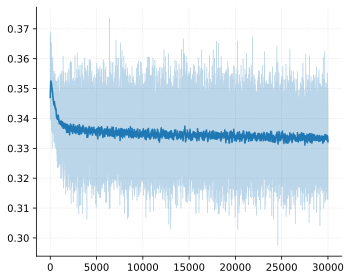

In [28]:
#| code-fold: true
from notebooks.plot import Plot

p = Plot()
p[0].line(history["train"], color="C0", label="train", smooth=100)
p.show()

# plt.figure(figsize=(5, 3))
# plt.plot(history["train"], label="train")
# plt.plot(history["valid_steps"], history["valid"], label="valid")
# plt.ylabel("loss")
# plt.xlabel("step")
# plt.legend()
# plt.grid(linestyle="dotted", alpha=0.6);

In [26]:
print(evaluate(trainer, x_train, y_train, t=0.5)["message"]); print()
print(evaluate(trainer, x_valid, y_valid, t=0.5)["message"])

[[   0 3243]
 [   0 4757]]
m=8000, f1=0.44346, t=0.50000

[[   0  786]
 [   0 1214]]
m=2000, f1=0.45856, t=0.50000


There are two ways to improve the threshold `t` (both not free, i.e. requires some assumptions):

**1. Matching the label prior distribution.** The threshold for predicting hard labels can be calibrated by using the prior label distribution. This significantly improves F1. Here we use the entirety of our data (i.e. `x`):

In [27]:
from collections import Counter

calibration_score = [] # lower = better
thresholds = np.linspace(-1, 1, num=500)
for t in thresholds:
    c = Counter(trainer.predict(x, t).tolist())
    n = len(x)
    c[-1] = c[-1] / n 
    c[+1] = c[+1] / n 
    calibration_score.append(-LABEL_PROBS[-1] * np.log(c[-1]) + -LABEL_PROBS[+1] * np.log(c[+1]))


t_best = thresholds[np.argmin(calibration_score)]
print(evaluate(trainer, x_train, y_train, t=t_best)["message"]); print()
print(evaluate(trainer, x_valid, y_valid, t=t_best)["message"])

[[3175   68]
 [  48 4709]]
m=8000, f1=0.98549, t=0.58717

[[ 769   17]
 [   5 1209]]
m=2000, f1=0.98898, t=0.58717


:::{.callout-note }
This calibration uses the **entire** dataset `x` (both train and valid) and assumes exact [knowledge of the class prior]{.mark} `LABEL_PROBS`. The cross-entropy objective selects the threshold $t$ whose predicted label distribution best matches the prior. If the prior estimate is inaccurate, the selected [decision threshold]{.underline} shifts accordingly: overestimating $p(y=+1)$ pushes $t$ lower (more positive predictions), while underestimating it pushes $t$ higher. In practice, the class prior is rarely known exactly, so this approach is sensitive to estimation error &mdash; especially for imbalanced problems.
:::

**2. Tuning on a labeled subset.** If a representative subset of the data is labeled, even if small, then we can use that to tune the threshold. The following iteratively finds the threshold that maximizes weighted F1 on the validation set:

[[3191   52]
 [  71 4686]]
m=8000, f1=0.98463, t=0.58759

[[581   9]
 [  6 904]]
m=1500, f1=0.99000, t=0.58759


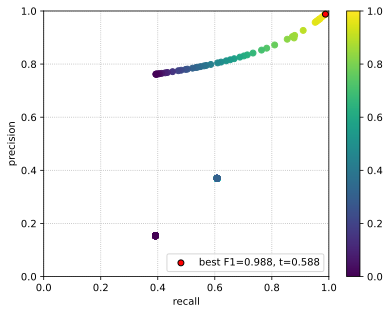

In [28]:
def pr_curve(model, x, y, num_thresholds, min_t=0.0, max_t=1.0):
    p, r, t, f = [], [], [], []
    for threshold in np.linspace(min_t, max_t, num_thresholds):
        preds = model.predict(x, threshold).numpy()
        f.append(f1_score(y.numpy(), preds, average="weighted"))
        r.append(recall_score(y.numpy(), preds, average="weighted"))
        p.append(precision_score(y.numpy(), preds, average="weighted"))
        t.append(threshold)
    
    return p, r, t, f

def plot_pr_curve(model, x, y, num_thresholds=200, min_t=0.0, max_t=1.0):
    """Tune threshold based on validation set."""
    p, r, t, f = pr_curve(model, x, y, num_thresholds, min_t, max_t);
    t_best_idx = np.argmax(f)
    t_best = t[t_best_idx]

    # plotting the sample F1s
    plt.grid(linestyle="dotted", zorder=0)
    plt.scatter(r, p, c=f, zorder=2)
    plt.scatter(x=r[t_best_idx], y=p[t_best_idx], edgecolor="k", facecolor="red", label=f"best F1={f[t_best_idx]:.3f}, t={t_best:.3f}", zorder=3)
    plt.colorbar()
    plt.xlabel("recall")
    plt.ylabel("precision")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend(loc="lower right")

    return t_best


# Tuning the threshold on a labeled subset (here 500 pts)
t_best = plot_pr_curve(trainer, x_valid[:500], y_valid[:500], num_thresholds=1000, min_t=0.0, max_t=1.0)
print(evaluate(trainer, x_train, y_train, t=t_best)["message"]); print()
print(evaluate(trainer, x_valid[500:], y_valid[500:], t=t_best)["message"])

**Remark.** Model has learned fairly well despite having suboptimal LFs.

---

## Application: IMDB Movie Reviews

We apply the same weak supervision pipeline to a real text classification task: **IMDB movie review sentiment analysis**. The key challenge is adapting our `GenModel` and `NoiseAwareTrainer` (designed for tensor inputs) to work with raw text data. We define text-based labeling functions that detect sentiment patterns, wrap them to be tensor-compatible, and use TF-IDF features to train the noise-aware discriminative model.

In [25]:
import re
import pandas as pd
from datasets import load_dataset

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# Load IMDB dataset (3000 train, 1000 valid)
ds = load_dataset("imdb")
train_ds = ds["train"].shuffle(seed=RANDOM_SEED).select(range(3000))
valid_ds = ds["test"].shuffle(seed=RANDOM_SEED).select(range(1000))

train_texts = train_ds["text"]
valid_texts = valid_ds["text"]
y_train_imdb = torch.tensor([2 * label - 1 for label in train_ds["label"]])  # {0,1} -> {-1,+1}
y_valid_imdb = torch.tensor([2 * label - 1 for label in valid_ds["label"]])

POSITIVE, NEGATIVE, ABSTAIN = 1, -1, 0


# (1) Strong adjectives
def lf_strong_sentiment(text):
    text = text.lower()
    pos_words = ["excellent", "masterpiece", "outstanding", "brilliant", "perfect", "superb", "fantastic", "wonderful"]
    neg_words = ["terrible", "awful", "horrible", "worst", "dreadful", "atrocious", "abysmal", "pathetic"]
    pos = any(w in text for w in pos_words)
    neg = any(w in text for w in neg_words)
    if pos and not neg: return POSITIVE
    if neg and not pos: return NEGATIVE
    return ABSTAIN


# (2) Balance of positive/negative word counts
def lf_sentiment_words(text):
    text = text.lower()
    pos_words = ["great", "love", "amazing", "best", "enjoyed", "favorite", "fun"]
    neg_words = ["bad", "waste", "boring", "poor", "stupid", "annoying", "disappointing"]
    pos_count = sum(1 for w in pos_words if w in text)
    neg_count = sum(1 for w in neg_words if w in text)
    if pos_count > neg_count: return POSITIVE
    if neg_count > pos_count: return NEGATIVE
    return ABSTAIN


# (3) Explicit ratings (e.g. "10/10", "1 star")
def lf_rating_mention(text):
    text = text.lower()
    pos_patterns = [r"10/10", r"10 out of 10", r"5 stars", r"5/5"]
    neg_patterns = [r"1/10", r"1 out of 10", r"1 star[^s]", r"0 stars", r"0/10"]
    pos = any(re.search(p, text) for p in pos_patterns)
    neg = any(re.search(p, text) for p in neg_patterns)
    if pos and not neg: return POSITIVE
    if neg and not pos: return NEGATIVE
    return ABSTAIN


# (4) Re-watch / walk-out behavior
def lf_viewing_experience(text):
    text_lower = text.lower()
    pos_watch = ["watched twice", "seen it multiple times", "watch again", "rewatch", "couldn't stop watching"]
    neg_watch = ["walked out", "turned it off", "fell asleep", "couldn't finish", "wasted 2 hours"]
    pos = any(p in text_lower for p in pos_watch)
    neg = any(n in text_lower for n in neg_watch)
    if pos and not neg: return POSITIVE
    if neg and not pos: return NEGATIVE
    return ABSTAIN


# (5) Negative comparative phrases
def lf_comparative_sentiment(text):
    text_lower = text.lower()
    if "worse than" in text_lower or "not as good as" in text_lower or "disappointing compared" in text_lower:
        return NEGATIVE
    return ABSTAIN


# (6) Recommendation / avoidance phrases
def lf_recommendation(text):
    text = text.lower()
    pos_phrases = ["highly recommend", "must see", "must watch", "worth watching", "go see", "definitely watch", "check it out"]
    neg_phrases = ["do not recommend", "don't recommend", "avoid", "skip this", "don't bother", "don't waste", "stay away", "save your"]
    pos = any(p in text for p in pos_phrases)
    neg = any(p in text for p in neg_phrases)
    if pos and not neg: return POSITIVE
    if neg and not pos: return NEGATIVE
    return ABSTAIN


# (7) Exclamation + sentiment phrases
def lf_exclamation_sentiment(text):
    if "!" not in text: return ABSTAIN
    text = text.lower()
    pos_phrases = ["loved it", "great film", "great movie", "must see", "highly recommended", "well done"]
    neg_phrases = ["waste of time", "don't watch", "stay away", "save your money", "never again", "so bad"]
    pos = any(p in text for p in pos_phrases)
    neg = any(p in text for p in neg_phrases)
    if pos and not neg: return POSITIVE
    if neg and not pos: return NEGATIVE
    return ABSTAIN


text_lfs_raw = [
    lf_strong_sentiment,
    lf_sentiment_words,
    lf_rating_mention,
    lf_viewing_experience,
    lf_comparative_sentiment,
    lf_recommendation,
    lf_exclamation_sentiment,
]

# Coverage and accuracy on train set
stats = []
for lf in text_lfs_raw:
    outputs = [lf(t) for t in train_texts]
    labels = y_train_imdb.numpy()
    fired = [i for i, o in enumerate(outputs) if o != 0]
    cov = len(fired) / len(outputs)
    acc = sum(1 for i in fired if outputs[i] == labels[i]) / max(len(fired), 1)
    stats.append({
        "LF": lf.__name__,
        "coverage": f"{cov:.3f}",
        "accuracy": f"{acc:.3f}",
    })

pd.DataFrame(stats)

,LF,coverage,accuracy
0,lf_strong_sentiment,0.414,0.881
1,lf_sentiment_words,0.691,0.756
2,lf_rating_mention,0.023,0.812
3,lf_viewing_experience,0.011,0.812
4,lf_comparative_sentiment,0.013,0.800
5,lf_recommendation,0.112,0.798
6,lf_exclamation_sentiment,0.051,0.810


**Adapting text LFs.** Our `GenModel` and `NoiseAwareTrainer` call `lf(x)` where `x` is a tensor. To bridge this gap, we precompute LF outputs for all texts and wrap them in a `TextLF` class that returns cached results based on the input tensor size. We also extract TF-IDF features as the input representation for the discriminative model:

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer


class TextLF:
    """Wraps a text LF for tensor-based GenModel/NoiseAwareTrainer."""

    def __init__(self, lf_func, texts_train, texts_valid):
        self._cache = {
            len(texts_train): torch.tensor([lf_func(t) for t in texts_train]),
            len(texts_valid): torch.tensor([lf_func(t) for t in texts_valid]),
        }

    def __call__(self, x):
        return self._cache[x.shape[0]]  # (1)


text_lfs = [TextLF(lf, train_texts, valid_texts) for lf in text_lfs_raw]

vectorizer = TfidfVectorizer(max_features=5000)
x_train_imdb = torch.tensor(
    vectorizer.fit_transform(train_texts).toarray(), dtype=torch.float32
)
x_valid_imdb = torch.tensor(
    vectorizer.transform(valid_texts).toarray(), dtype=torch.float32
)

print(f"x_train: {x_train_imdb.shape}")
print(f"x_valid: {x_valid_imdb.shape}")

x_train: torch.Size([3000, 5000])
x_valid: torch.Size([1000, 5000])


**Generative model.** We train `GenModel` on the text LF outputs with a balanced prior. The model learns the latent coverage and accuracy of each LF, and produces soft labels $p(y \mid \Lambda_i)$ for every review:

In [31]:
IMDB_LABEL_PROBS = {-1: 0.50, 1: 0.50}

gen_model_imdb = GenModel(text_lfs, IMDB_LABEL_PROBS)
history_gen_imdb = gen_model_imdb.fit(
    x_train_imdb, x_valid_imdb,
    bs=3000, epochs=15000, lr=0.003, lr_decay=0.8,
)


  0%|          | 0/15000 [00:00<?, ?it/s]


  1%|          | 150/15000 [00:00<00:09, 1496.35it/s]


  2%|▏         | 312/15000 [00:00<00:09, 1566.57it/s]


  3%|▎         | 475/15000 [00:00<00:09, 1592.67it/s]


  4%|▍         | 638/15000 [00:00<00:08, 1607.21it/s]

...


 96%|█████████▌| 14408/15000 [00:08<00:00, 1651.33it/s]


 97%|█████████▋| 14574/15000 [00:08<00:00, 1651.74it/s]


 98%|█████████▊| 14740/15000 [00:09<00:00, 1651.51it/s]


 99%|█████████▉| 14906/15000 [00:09<00:00, 1650.34it/s]


100%|██████████| 15000/15000 [00:09<00:00, 1629.75it/s]

Training and validation NLL for the generative model:

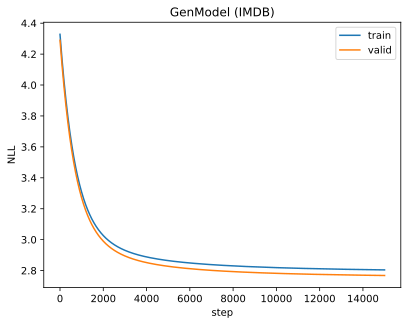

In [32]:
#| code-fold: true
plt.figure(figsize=(5, 3))
plt.plot(history_gen_imdb["train"], label="train")
plt.plot(history_gen_imdb["valid_steps"], history_gen_imdb["valid"], label="valid")
plt.legend()
plt.xlabel("step")
plt.ylabel("NLL")
plt.grid(linestyle="dotted", alpha=0.6);

**Noise-aware training.** We train an MLP on TF-IDF features using the noise-aware loss, weighted by the generative model's soft labels. The discriminative model can generalize beyond the keywords used in the LFs by leveraging the full TF-IDF vocabulary:

In [33]:
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

clf_imdb = nn.Sequential(nn.Linear(5000, 32), nn.SELU(), nn.Linear(32, 1))
trainer_imdb = NoiseAwareTrainer(clf_imdb, gen_model_imdb, text_lfs)
history_nat_imdb = trainer_imdb.run(
    x_train_imdb, x_valid_imdb,
    epochs=200, bs=64, lr=0.01, alpha=0.0, momentum=0.9,
)


  0%|          | 0/200 [00:00<?, ?it/s]


  2%|▏         | 3/200 [00:00<00:07, 26.24it/s]


  4%|▎         | 7/200 [00:00<00:06, 30.58it/s]


  6%|▌         | 11/200 [00:00<00:05, 32.09it/s]


  8%|▊         | 15/200 [00:00<00:05, 32.79it/s]

...


 88%|████████▊ | 175/200 [00:05<00:00, 35.01it/s]


 90%|████████▉ | 179/200 [00:05<00:00, 35.11it/s]


 92%|█████████▏| 183/200 [00:05<00:00, 35.29it/s]


 93%|█████████▎| 186/200 [00:05<00:00, 34.00it/s]

Early stopping at epoch 186...
Training stopped.
Best valid loss: 0.281686395406723


Training and validation loss for the noise-aware discriminative model:

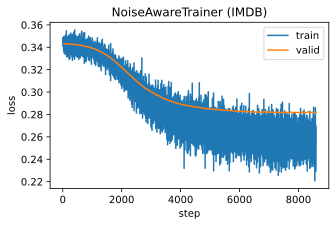

In [34]:
#| code-fold: true
plt.figure(figsize=(5, 3))
plt.plot(history_nat_imdb["train"], label="train")
plt.plot(history_nat_imdb["valid_steps"], history_nat_imdb["valid"], label="valid")
plt.legend()
plt.xlabel("step")
plt.ylabel("loss")
plt.grid(linestyle="dotted", alpha=0.6);

**Evaluation.** Comparing the generative model (LF outputs only) with the noise-aware discriminative model (TF-IDF features):

In [35]:
print("GenModel (IMDB):")
print(evaluate(gen_model_imdb, x_train_imdb, y_train_imdb, t=0.5)["message"]); print()
print(evaluate(gen_model_imdb, x_valid_imdb, y_valid_imdb, t=0.5)["message"])

print("\nNoiseAwareTrainer (IMDB):")
print(evaluate(trainer_imdb, x_train_imdb, y_train_imdb, t=0.5)["message"]); print()
print(evaluate(trainer_imdb, x_valid_imdb, y_valid_imdb, t=0.5)["message"])

GenModel (IMDB):
[[ 830  678]
 [ 112 1380]]
m=3000, f1=0.72724, t=0.50000

[[294 213]
 [ 34 459]]
m=1000, f1=0.74550, t=0.50000

NoiseAwareTrainer (IMDB):
[[1000  508]
 [ 152 1340]]
m=3000, f1=0.77700, t=0.50000

[[343 164]
 [ 35 458]]
m=1000, f1=0.79801, t=0.50000


:::{.callout-note }
The noise-aware model outperforms the generative model on IMDB reviews. While the generative model can only make predictions based on the [7 labeling function outputs]{.mark} (at most $3^7 = 2187$ unique patterns), the discriminative model leverages [5000 TF-IDF features]{.mark} to capture sentiment signals beyond the keywords hardcoded in our LFs. This demonstrates the core value of the data programming pipeline: noisy LFs provide initial supervision, and the discriminative model generalizes from there.
:::

---